# 00 - Exploratory Data Analysis (EDA)

**Goal**: Understand the hotel bookings dataset structure, quality, and key patterns.

**No modeling** - only data checks, visualizations, and insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline


## 1. Load Data

In [2]:
# Config
DATA_PATH = Path("..") / "data" / "hotel_bookings.csv"
TARGET_COL = "is_canceled"

def load_data(path: Path) -> pd.DataFrame:
    return pd.read_csv(path)

# Load dataset using a relative, Path-based location
df = load_data(DATA_PATH)
print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


Dataset loaded: 119,390 rows x 32 columns


## 2. Dataset Overview

In [3]:
# Display first few rows
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [5]:
# Statistical summary (numeric)
df.describe()

# Categorical summary
cat_cols = df.select_dtypes(include=['object']).columns
if len(cat_cols) > 0:
    cat_summary = df[cat_cols].describe().T
    display(cat_summary)

    top_k = 5
    max_cols = 8
    for col in cat_cols[:max_cols]:
        print()
        print(f"Top {top_k} values for {col}:")
        print(df[col].value_counts().head(top_k))
else:
    print("No categorical columns found")


,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613



Top 5 values for hotel:
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

Top 5 values for arrival_date_month:
arrival_date_month
August     13877
July       12661
May        11791
October    11160
April      11089
Name: count, dtype: int64

Top 5 values for meal:
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64

Top 5 values for country:
country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
Name: count, dtype: int64

Top 5 values for market_segment:
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Name: count, dtype: int64

Top 5 values for distribution_channel:
distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64

Top 5 values for reserved_room_type:
reserved_room_type
A    85994
D    19201
E   

## 3. Missingness Report

In [6]:
# Calculate missing values
missing = pd.DataFrame({
    'column': df.columns,
    'missing_count': df.isnull().sum().values,
    'missing_pct': (df.isnull().sum().values / len(df) * 100).round(2)
})
missing = missing[missing['missing_count'] > 0].sort_values('missing_count', ascending=False)

if len(missing) > 0:
    print()
    print("??  Columns with missing values:")
    print(missing.to_string(index=False))
else:
    print("? No missing values detected")

reports_dir = Path("..") / "reports"
reports_dir.mkdir(exist_ok=True)
missing_path = reports_dir / "missingness_report.csv"
missing.to_csv(missing_path, index=False)
print(f"Saved missingness report to: {missing_path}")



??  Columns with missing values:
  column  missing_count  missing_pct
 company         112593        94.31
   agent          16340        13.69
 country            488         0.41
children              4         0.00
Saved missingness report to: ..\reports\missingness_report.csv


In [7]:
# Data quality checks
total_guests = df["adults"].fillna(0) + df["children"].fillna(0) + df["babies"].fillna(0)
total_nights = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

dq = pd.DataFrame({
    "check": [
        "duplicate_rows",
        "zero_guest_bookings",
        "zero_night_stays",
        "adr_zero_or_negative",
    ],
    "count": [
        df.duplicated().sum(),
        (total_guests == 0).sum(),
        (total_nights == 0).sum(),
        (df["adr"] <= 0).sum(),
    ]
})
dq["pct"] = (dq["count"] / len(df) * 100).round(2)
print("Data quality checks:")
print(dq.to_string(index=False))

reports_dir = Path("..") / "reports"
reports_dir.mkdir(exist_ok=True)
dq_path = reports_dir / "data_quality_checks.csv"
dq.to_csv(dq_path, index=False)
print(f"Saved data quality checks to: {dq_path}")


Data quality checks:
               check  count   pct
      duplicate_rows  31994 26.80
 zero_guest_bookings    180  0.15
    zero_night_stays    715  0.60
adr_zero_or_negative   1960  1.64


Saved data quality checks to: ..\reports\data_quality_checks.csv


## 4. Target Variable Analysis

In [8]:
# Cancellation rate
target_col = TARGET_COL
cancellation_rate = df[target_col].mean()
print(f"Overall Cancellation Rate: {cancellation_rate:.2%}")
print(f"\nClass distribution:")
print(df[target_col].value_counts())
print(f"\nClass balance:")
print(df[target_col].value_counts(normalize=True))

Overall Cancellation Rate: 37.04%

Class distribution:
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Class balance:
is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64


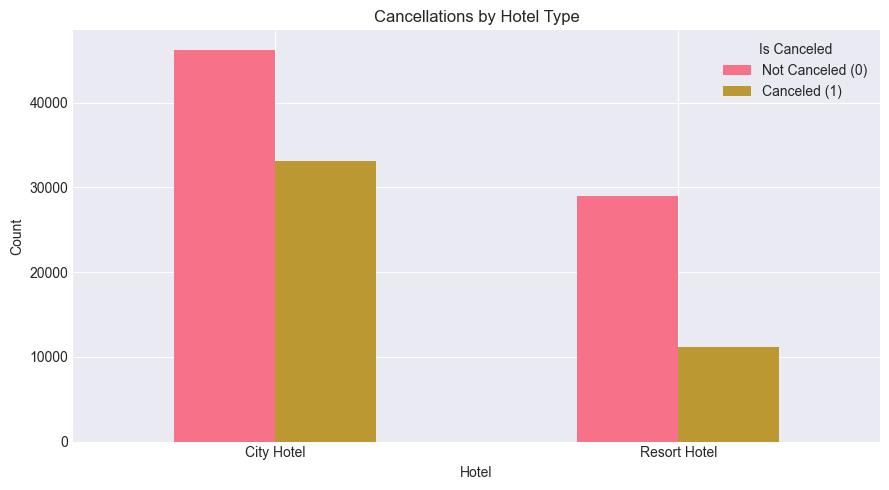

In [9]:
target_col = TARGET_COL  # or your target_col variable

# counts by hotel x cancel status
ct = pd.crosstab(df["hotel"], df[target_col])

# ensure consistent column order (0 then 1)
ct = ct.reindex(columns=sorted(ct.columns))

ax = ct.plot(kind="bar", figsize=(9,5))
ax.set_title("Cancellations by Hotel Type")
ax.set_xlabel("Hotel")
ax.set_ylabel("Count")
ax.set_xticklabels(ct.index, rotation=0)
ax.legend(["Not Canceled (0)", "Canceled (1)"], title="Is Canceled")
plt.tight_layout()
plt.show()


## 5. Data Leakage Check

In [10]:
# Identify leakage columns
leakage_columns = ['reservation_status', 'reservation_status_date']
present_leakage = [col for col in leakage_columns if col in df.columns]

if present_leakage:
    print(f"⚠️  LEAKAGE COLUMNS DETECTED: {present_leakage}")
    print("These columns must be dropped before modeling as they leak target information.")
    
    # Show relationship between reservation_status and is_canceled
    if 'reservation_status' in df.columns:
        print("\nReservation Status vs Cancellation:")
        print(pd.crosstab(df['reservation_status'], df['is_canceled'], normalize='index'))
else:
    print("✓ No known leakage columns found")

⚠️  LEAKAGE COLUMNS DETECTED: ['reservation_status', 'reservation_status_date']
These columns must be dropped before modeling as they leak target information.

Reservation Status vs Cancellation:
is_canceled           0    1
reservation_status          
Canceled            0.0  1.0
Check-Out           1.0  0.0
No-Show             0.0  1.0


## 6. ADR (Average Daily Rate) Analysis

In [11]:
# ADR summary statistics
print("ADR Summary Statistics:")
print(df['adr'].describe())

# Check for outliers
adr_q1 = df['adr'].quantile(0.25)
adr_q3 = df['adr'].quantile(0.75)
adr_iqr = adr_q3 - adr_q1
adr_lower = adr_q1 - 1.5 * adr_iqr
adr_upper = adr_q3 + 1.5 * adr_iqr

outliers = df[(df['adr'] < adr_lower) | (df['adr'] > adr_upper)]
print(f"\n⚠️  ADR Outliers (IQR method): {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")
print(f"   Lower bound: {adr_lower:.2f}")
print(f"   Upper bound: {adr_upper:.2f}")

# Check for negative or zero ADR
negative_adr = df[df['adr'] <= 0]
print(f"\nNegative or Zero ADR entries: {len(negative_adr):,} ({len(negative_adr)/len(df)*100:.2f}%)")

ADR Summary Statistics:
count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

⚠️  ADR Outliers (IQR method): 3,793 (3.18%)
   Lower bound: -15.77
   Upper bound: 211.06

Negative or Zero ADR entries: 1,960 (1.64%)


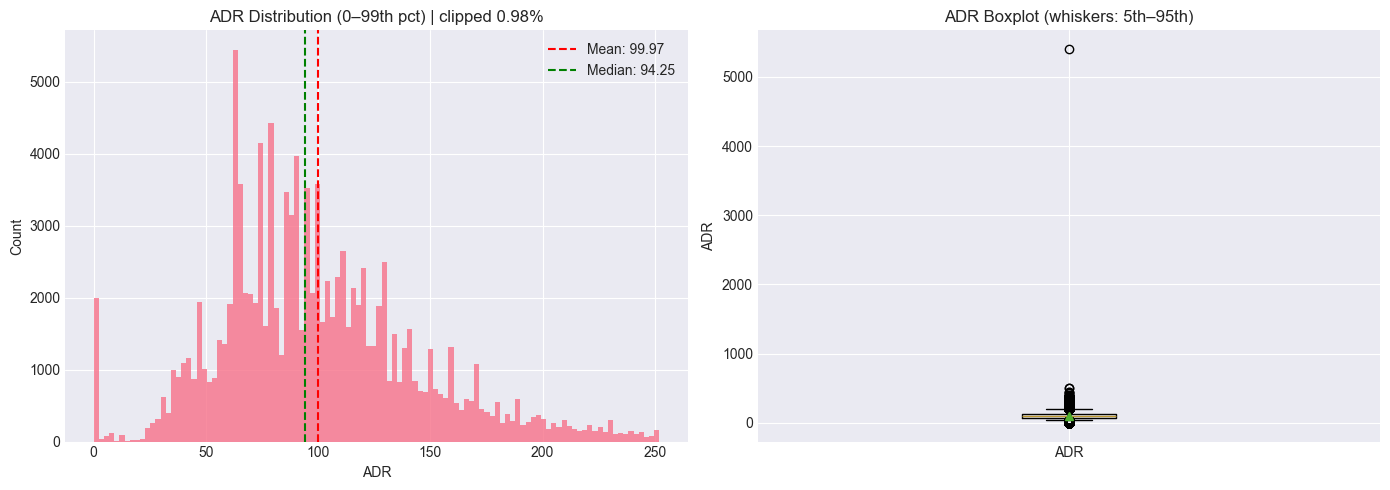

In [12]:
adr = df["adr"].dropna()

q99 = adr.quantile(0.99)
mask_zoom = (adr >= 0) & (adr <= q99)
adr_zoom = adr[mask_zoom]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (zoomed to 0–99th percentile)
axes[0].hist(adr_zoom, bins="fd", alpha=0.8, edgecolor="none")
axes[0].axvline(adr_zoom.mean(), color="red", linestyle="--", label=f"Mean: {adr_zoom.mean():.2f}")
axes[0].axvline(adr_zoom.median(), color="green", linestyle="--", label=f"Median: {adr_zoom.median():.2f}")
axes[0].set_title(f"ADR Distribution (0–99th pct) | clipped {(~mask_zoom).mean()*100:.2f}%")
axes[0].set_xlabel("ADR")
axes[0].set_ylabel("Count")
axes[0].legend()

# Boxplot (with percentile whiskers so tail doesn't dominate)
axes[1].boxplot(
    adr[adr >= 0],
    vert=True,
    whis=(5, 95),      # whiskers at 5th and 95th percentiles
    showmeans=True
)
axes[1].set_title("ADR Boxplot (whiskers: 5th–95th)")
axes[1].set_ylabel("ADR")
axes[1].set_xticks([1])
axes[1].set_xticklabels(["ADR"])

plt.tight_layout()
plt.show()


## 7. Time-Based Analysis

In [13]:
# Create arrival date column (robust parsing)
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'].astype(str) + '-' +
    df['arrival_date_day_of_month'].astype(str).str.zfill(2),
    format='%Y-%B-%d',
    errors='coerce'
)
n_nat = df['arrival_date'].isna().sum()
if n_nat:
    print(f'WARNING: arrival_date parse failures: {n_nat:,}')

# Create year-month column for aggregation
df['arrival_year_month'] = df['arrival_date'].dt.to_period('M')

print(f"Date range: {df['arrival_date'].min()} to {df['arrival_date'].max()}")


Date range: 2015-07-01 00:00:00 to 2017-08-31 00:00:00


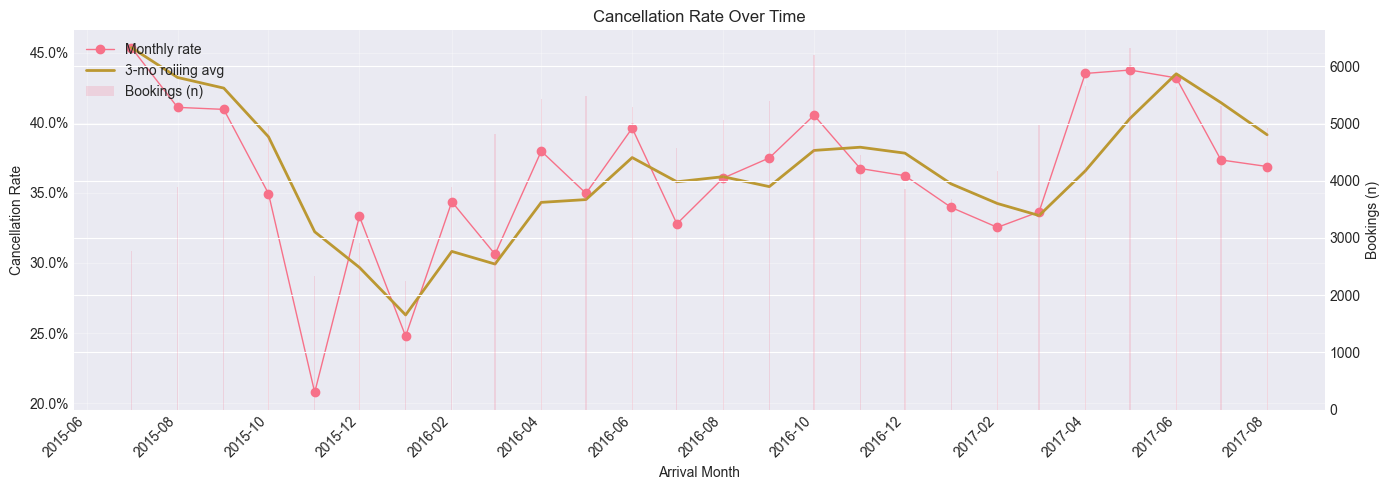

In [14]:
from matplotlib.ticker import PercentFormatter

target_col = TARGET_COL  # or your variable

# 1) Make sure arrival_year_month is datetime and sorted
df["arrival_year_month"] = pd.to_datetime(df["arrival_year_month"].astype(str), errors="coerce")

cancel_by_month = (
    df.dropna(subset=["arrival_year_month", target_col])
      .groupby("arrival_year_month")[target_col]
      .agg(rate="mean", n="size")
      .reset_index()
      .sort_values("arrival_year_month")
)

# 2) Rolling average (optional but recommended)
cancel_by_month["rate_roll3"] = cancel_by_month["rate"].rolling(3, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 5))

# Rate + rolling rate
ax.plot(cancel_by_month["arrival_year_month"], cancel_by_month["rate"], marker="o", linewidth=1, label="Monthly rate")
ax.plot(cancel_by_month["arrival_year_month"], cancel_by_month["rate_roll3"], linewidth=2, label="3-mo rolling avg")

ax.set_title("Cancellation Rate Over Time")
ax.set_xlabel("Arrival Month")
ax.set_ylabel("Cancellation Rate")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(True, alpha=0.3)

# 3) Booking volume on secondary axis (bars)
ax2 = ax.twinx()
ax2.bar(cancel_by_month["arrival_year_month"], cancel_by_month["n"], alpha=0.2, label="Bookings (n)")
ax2.set_ylabel("Bookings (n)")

# 4) Cleaner x-axis ticks
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # every 2 months
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Combined legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc="upper left")

plt.tight_layout()
plt.show()


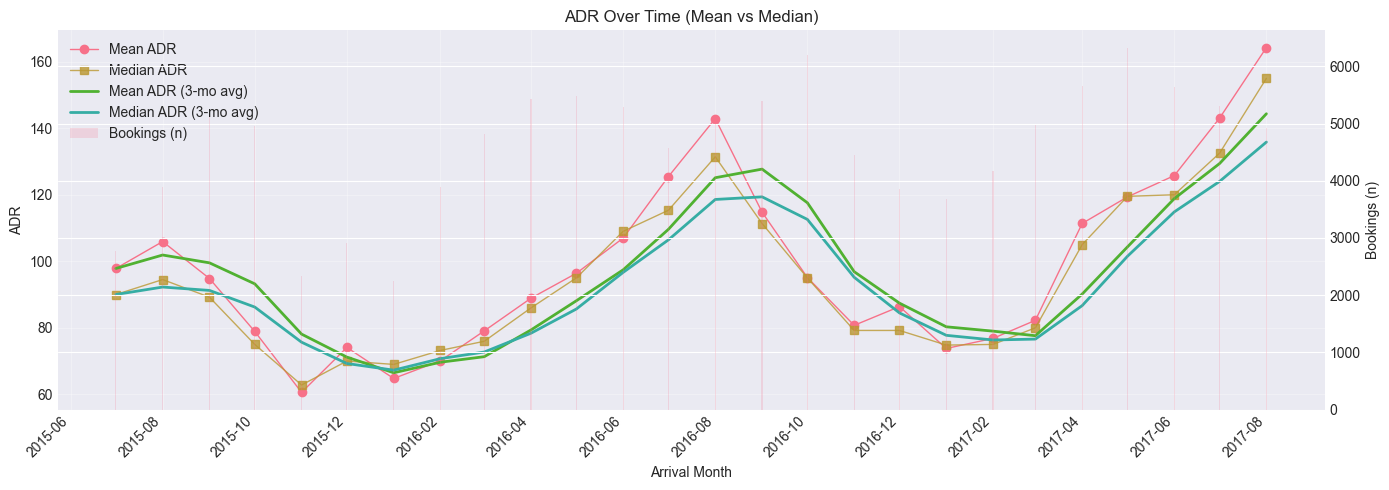

In [15]:
# Ensure datetime month
df["arrival_year_month"] = pd.to_datetime(df["arrival_year_month"].astype(str), errors="coerce")

adr_by_month = (
    df.dropna(subset=["arrival_year_month", "adr"])
      .groupby("arrival_year_month")["adr"]
      .agg(mean="mean", median="median", n="size")
      .reset_index()
      .sort_values("arrival_year_month")
)

# Optional smoothing (3-month rolling)
adr_by_month["mean_roll3"] = adr_by_month["mean"].rolling(3, min_periods=1).mean()
adr_by_month["median_roll3"] = adr_by_month["median"].rolling(3, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(adr_by_month["arrival_year_month"], adr_by_month["mean"], marker="o", linewidth=1, label="Mean ADR")
ax.plot(adr_by_month["arrival_year_month"], adr_by_month["median"], marker="s", linewidth=1, alpha=0.8, label="Median ADR")

# Smoothed lines (thicker)
ax.plot(adr_by_month["arrival_year_month"], adr_by_month["mean_roll3"], linewidth=2, label="Mean ADR (3-mo avg)")
ax.plot(adr_by_month["arrival_year_month"], adr_by_month["median_roll3"], linewidth=2, label="Median ADR (3-mo avg)")

ax.set_title("ADR Over Time (Mean vs Median)")
ax.set_xlabel("Arrival Month")
ax.set_ylabel("ADR")
ax.grid(True, alpha=0.3)

# Secondary axis for volume (n)
ax2 = ax.twinx()
ax2.bar(adr_by_month["arrival_year_month"], adr_by_month["n"], alpha=0.2, label="Bookings (n)")
ax2.set_ylabel("Bookings (n)")

# Cleaner ticks
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Combined legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc="upper left")

plt.tight_layout()
plt.show()


## Average Guests per Month
This chart shows the average number of guests per booking for each calendar month, split by hotel type.

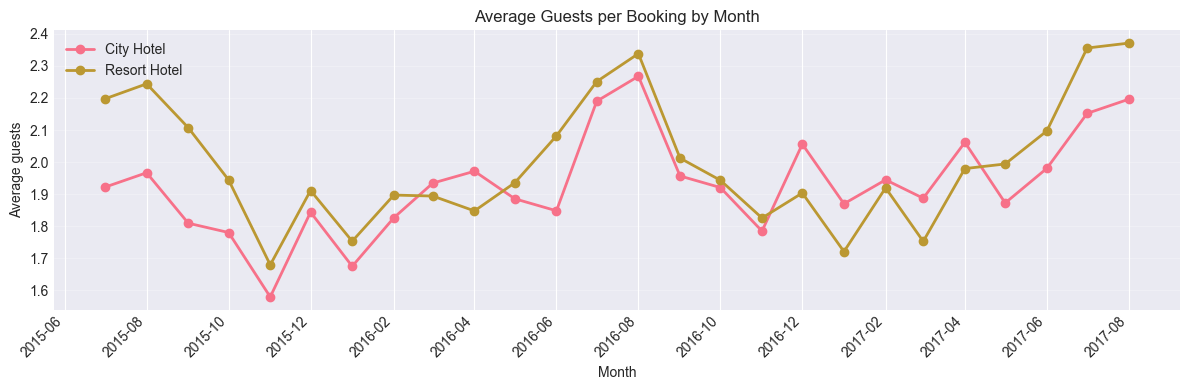

In [16]:
d = df.copy()
for c in ["adults", "children", "babies"]:
    d[c] = d[c].fillna(0).clip(lower=0)

d["total_guests"] = d["adults"] + d["children"] + d["babies"]

d["month"] = pd.to_datetime(
    d["arrival_date_year"].astype(str) + "-" + d["arrival_date_month"].astype(str) + "-01",
    errors="coerce"
)
d = d.dropna(subset=["month"])

monthly = (d.groupby(["hotel", "month"], as_index=False)
             .agg(avg_guests=("total_guests", "mean"))
             .sort_values(["hotel", "month"]))

# --- Plot: clean, readable, one chart ---
fig, ax = plt.subplots(figsize=(12, 4))

for hotel in ["City Hotel", "Resort Hotel"]:
    x = monthly[monthly["hotel"] == hotel]
    ax.plot(x["month"], x["avg_guests"], marker="o", linewidth=2, label=hotel)

ax.set_title("Average Guests per Booking by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Average guests")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(frameon=False)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Average Price per Night and Person

This chart shows the average nightly price per person (ADR divided by total guests) by month, split by hotel type.

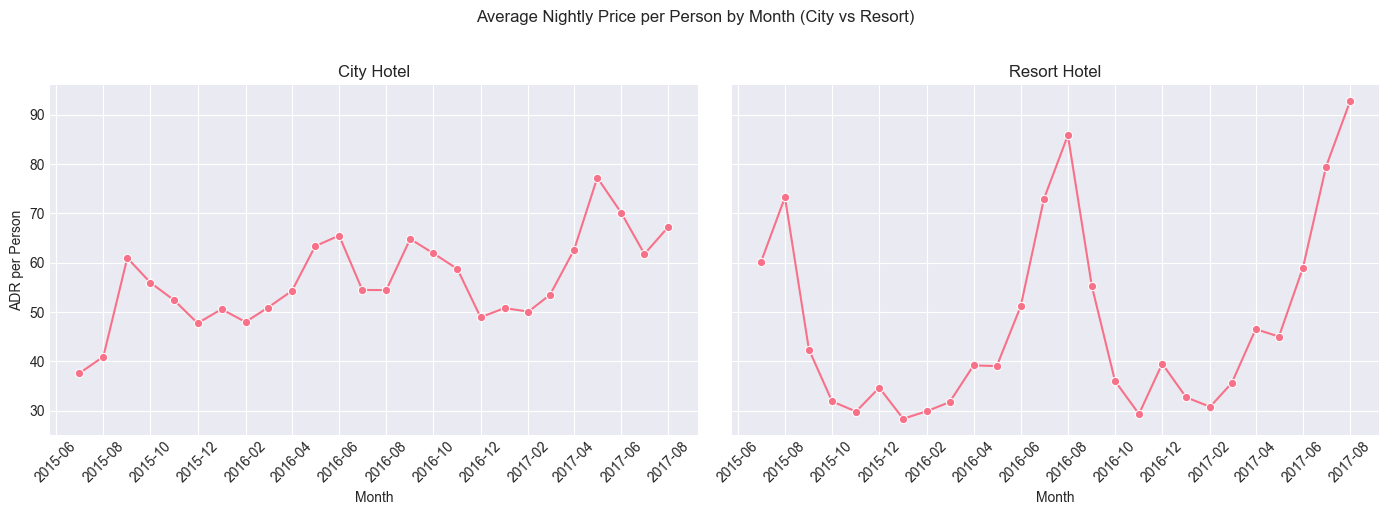

In [17]:
# Average nightly price per person by calendar month and hotel type (subplots)
df_price = df.copy()
df_price['children'] = df_price['children'].fillna(0)
df_price['total_guests'] = df_price['adults'] + df_price['children'] + df_price['babies']
df_price['adr_per_person'] = df_price['adr'] / df_price['total_guests'].replace(0, pd.NA)
df_price['arrival_month'] = pd.to_datetime(
    df_price['arrival_date_year'].astype(str) + '-' + df_price['arrival_date_month'].astype(str) + '-01',
    format='%Y-%B-%d',
    errors='coerce'
)
monthly_avg_price = (
    df_price.groupby(['hotel', 'arrival_month'], as_index=False)['adr_per_person']
    .mean()
    .dropna(subset=['arrival_month'])
    .sort_values('arrival_month')
)

hotels = ['City Hotel', 'Resort Hotel']
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, hotel in zip(axes, hotels):
    data = monthly_avg_price[monthly_avg_price['hotel'] == hotel]
    sns.lineplot(data=data, x='arrival_month', y='adr_per_person', marker='o', ax=ax)
    ax.set_title(hotel)
    ax.set_xlabel('Month')
    ax.set_ylabel('ADR per Person')
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Average Nightly Price per Person by Month (City vs Resort)', y=1.02)
plt.tight_layout()
plt.show()


## Bookings by Market Segment

This chart shows the number of bookings for each market segment.

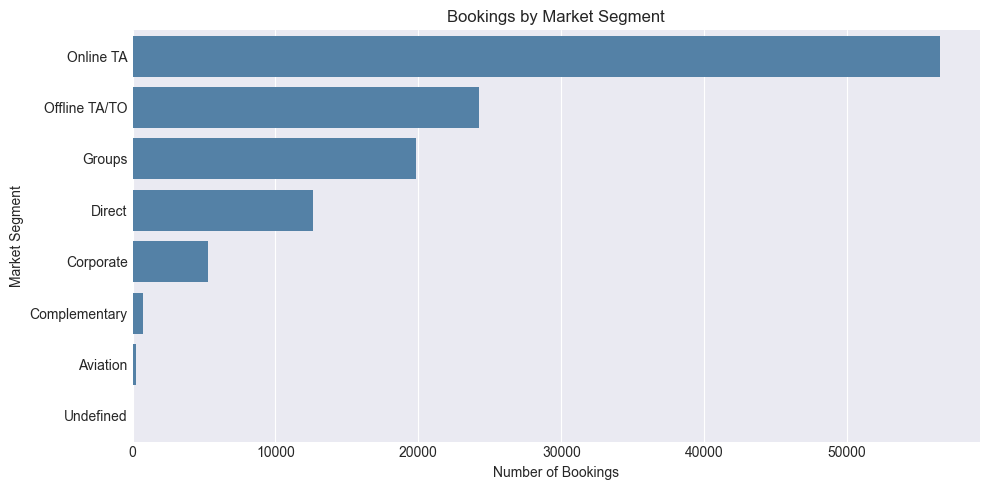

In [18]:
# Bookings by market segment
market_counts = (
    df['market_segment']
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=market_counts.values, y=market_counts.index, color='steelblue')
plt.title('Bookings by Market Segment')
plt.xlabel('Number of Bookings')
plt.ylabel('Market Segment')
plt.tight_layout()
plt.show()


## Length of Stay

This chart shows the distribution of total nights booked (weekend + weekday), split by hotel type.
The charts compare how long guests book to stay for City Hotel vs Resort Hotel.

The y-axis is share of bookings (percent), so the two hotels are directly comparable.

Bars are split by outcome: red = not canceled, yellow = canceled.

Both hotels are mostly short stays (about 1–4 nights).

City Hotel is concentrated around 2–4 nights.

Resort Hotel has more spread, with a noticeable chunk around ~7 nights (week-long stays).

The plot is capped at the 99th percentile (14 nights), meaning very long stays exist but are excluded so the main pattern is easier to see.

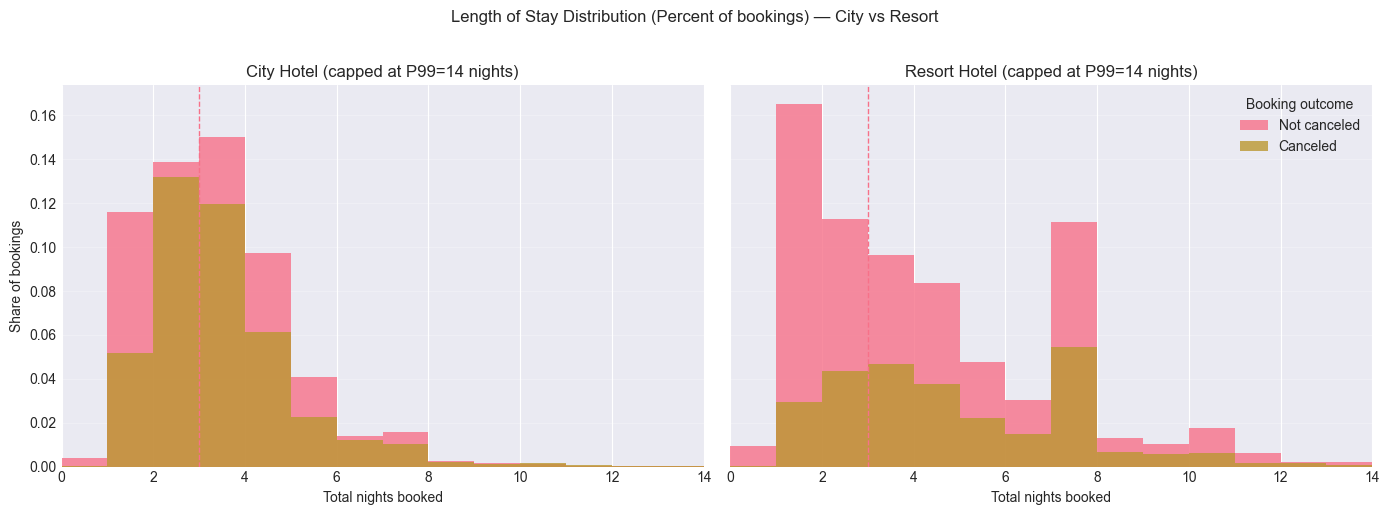

In [19]:
# --- Build total nights ---
df_stay = df.copy()
df_stay["total_nights"] = df_stay["stays_in_weekend_nights"] + df_stay["stays_in_week_nights"]

# --- Optional: cap extreme outliers so the plot is readable ---
# (keeps the distribution shape but avoids the 50–70 night tail dominating the x-axis)
cap = int(np.ceil(df_stay["total_nights"].quantile(0.99)))
df_plot = df_stay[df_stay["total_nights"].between(0, cap)].copy()

# Use integer-night bins for interpretability
bins = np.arange(0, cap + 2, 1)

hotels = ["City Hotel", "Resort Hotel"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, hotel in zip(axes, hotels):
    d = df_plot[df_plot["hotel"] == hotel]

    # Plot as percentages (so City vs Resort is comparable)
    # Split by cancellation status for more business meaning
    for label, mask in [("Not canceled", d["is_canceled"] == 0), ("Canceled", d["is_canceled"] == 1)]:
        x = d.loc[mask, "total_nights"].to_numpy()
        if len(x) == 0:
            continue
        weights = np.ones_like(x, dtype=float) / len(d)  # % of all bookings in this hotel
        ax.hist(x, bins=bins, weights=weights, alpha=0.8, label=label)

    # Add median reference line (overall for this hotel)
    med = d["total_nights"].median()
    ax.axvline(med, linestyle="--", linewidth=1)
    ax.set_title(f"{hotel} (capped at P99={cap} nights)")
    ax.set_xlabel("Total nights booked")
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_xlim(0, cap)

axes[0].set_ylabel("Share of bookings")
axes[1].legend(title="Booking outcome", frameon=False)

fig.suptitle("Length of Stay Distribution (Percent of bookings) — City vs Resort", y=1.02)
plt.tight_layout()
plt.show()


## Conclusion

EDA completed successfully. Key findings:
- Dataset contains booking records with temporal structure suitable for time-based splits
- Target variable shows class distribution appropriate for classification
- Critical leakage columns identified and must be removed
- ADR requires preprocessing for regression tasks
- Seasonal patterns observed in both cancellations and pricing

**Ready for modeling in subsequent notebooks.**